**Timeframe**: Data collected via a one‐time online survey administered in Q1 2025.

**Stakeholder** =
* Decider / Pengambil Keputusan
* Accountability / Akuntabel
* Responsible / Bertanggung Jawab
* Consulted / Dikonsultasikan
* Informed / Diinformasikan


# Import Dataset From Kagglehub

path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")

print("Path to dataset files:", path)

In [1]:
!pip install kagglehub

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import gdown
import kagglehub
import os

In [3]:
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")

print("Path to dataset files:", path)

print(os.listdir(path))

100%|██████████| 7.67k/7.67k [00:00<00:00, 12.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/adilshamim8/social-media-addiction-vs-relationships/versions/3
['Students Social Media Addiction.csv']


In [4]:
# Load the dataset into a pandas DataFrame
file_path = os.path.join(path, 'Students Social Media Addiction.csv')
df = pd.read_csv(file_path)

# Cleaning Data & Exploratory Data

In [5]:
print(2 + 3 * 2)

8


In [6]:
# Dataset information
df.info()

# Summary statistics
df.describe()

#df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [8]:
# jabarkan negara - naegaranya
df['Country'].unique()

array(['Bangladesh', 'India', 'USA', 'UK', 'Canada', 'Australia',
       'Germany', 'Brazil', 'Japan', 'South Korea', 'France', 'Spain',
       'Italy', 'Mexico', 'Russia', 'China', 'Sweden', 'Norway',
       'Denmark', 'Netherlands', 'Belgium', 'Switzerland', 'Austria',
       'Portugal', 'Greece', 'Ireland', 'New Zealand', 'Singapore',
       'Malaysia', 'Thailand', 'Vietnam', 'Philippines', 'Indonesia',
       'Taiwan', 'Hong Kong', 'Turkey', 'Israel', 'UAE', 'Egypt',
       'Morocco', 'South Africa', 'Nigeria', 'Kenya', 'Ghana',
       'Argentina', 'Chile', 'Colombia', 'Peru', 'Venezuela', 'Ecuador',
       'Uruguay', 'Paraguay', 'Bolivia', 'Costa Rica', 'Panama',
       'Jamaica', 'Trinidad', 'Bahamas', 'Iceland', 'Finland', 'Poland',
       'Romania', 'Hungary', 'Czech Republic', 'Slovakia', 'Croatia',
       'Serbia', 'Slovenia', 'Bulgaria', 'Estonia', 'Latvia', 'Lithuania',
       'Ukraine', 'Moldova', 'Belarus', 'Kazakhstan', 'Uzbekistan',
       'Kyrgyzstan', 'Tajikistan', 'A

In [9]:
# Standardisasi nama kolom (hilangkan spasi & huruf kecil semua)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

**Data Cleaning**

In [10]:
# Convert type data  avg_daily_usage_hours menjadi float
df['avg_daily_usage_hours'] = df['avg_daily_usage_hours'].astype(float)

In [11]:
# cek value avg_daily_usage_hours apakah ada yang bukan angka

df['avg_daily_usage_hours'].unique()

array([5.2, 2.1, 6. , 3. , 4.5, 7.2, 1.5, 5.8, 4. , 3.3, 4.8, 5.5, 2.8,
       6.5, 3.7, 4.2, 2. , 5. , 3.5, 4.7, 5.3, 2.5, 4.9, 5.7, 3.2, 6.1,
       3.8, 4.4, 2.2, 5.9, 3.6, 5.4, 2.6, 5.6, 3.1, 6.2, 3.9, 2.3, 4.6,
       2.7, 6.3, 2.4, 2.9, 5.1, 4.3, 4.1, 3.4, 6.4, 7. , 6.8, 6.9, 6.7,
       6.6, 7.1, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. , 8.1, 8.2, 8.3,
       8.4, 8.5])

In [12]:
# Cek missing values
print("Missing values per kolom: \n")
print(df.isnull().sum())

Missing values per kolom: 

student_id                      0
age                             0
gender                          0
academic_level                  0
country                         0
avg_daily_usage_hours           0
most_used_platform              0
affects_academic_performance    0
sleep_hours_per_night           0
mental_health_score             0
relationship_status             0
conflicts_over_social_media     0
addicted_score                  0
dtype: int64


In [13]:
duplicates = df.duplicated().sum()
print(f"\nJumlah duplikat: {duplicates}")



Jumlah duplikat: 0


In [14]:
# Cek duplicate
for coloumn_name in df.columns:
  print(df[coloumn_name].value_counts(sort=False).sort_index(ascending=False), "\n")

student_id
705    1
704    1
703    1
702    1
701    1
      ..
5      1
4      1
3      1
2      1
1      1
Name: count, Length: 705, dtype: int64 

age
24     26
23     34
22    147
21    156
20    165
19    163
18     14
Name: count, dtype: int64 

gender
Male      352
Female    353
Name: count, dtype: int64 

academic_level
Undergraduate    353
High School       27
Graduate         325
Name: count, dtype: int64 

country
Yemen           1
Vietnam         1
Venezuela       1
Vatican City    1
Uzbekistan      1
               ..
Armenia         1
Argentina       1
Andorra         1
Albania         1
Afghanistan     1
Name: count, Length: 110, dtype: int64 

avg_daily_usage_hours
8.5    1
8.4    1
8.3    1
8.2    1
8.1    1
      ..
2.3    4
2.2    2
2.1    1
2.0    1
1.5    1
Name: count, Length: 67, dtype: int64 

most_used_platform
YouTube       10
WhatsApp      54
WeChat        15
VKontakte     12
Twitter       30
TikTok       154
Snapchat      13
LinkedIn      21
LINE          1

**Per Kolom (Numerik)**

In [15]:
# EDA Numerik (misalnya harga, jumlah, revenue) secara bersamaan
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ["student_id"]]  # exclude id
print(df[numeric_cols].describe())

              age  avg_daily_usage_hours  sleep_hours_per_night  \
count  705.000000             705.000000             705.000000   
mean    20.659574               4.918723               6.868936   
std      1.399217               1.257395               1.126848   
min     18.000000               1.500000               3.800000   
25%     19.000000               4.100000               6.000000   
50%     21.000000               4.800000               6.900000   
75%     22.000000               5.800000               7.700000   
max     24.000000               8.500000               9.600000   

       mental_health_score  conflicts_over_social_media  addicted_score  
count           705.000000                   705.000000      705.000000  
mean              6.226950                     2.849645        6.436879  
std               1.105055                     0.957968        1.587165  
min               4.000000                     0.000000        2.000000  
25%               5.000000

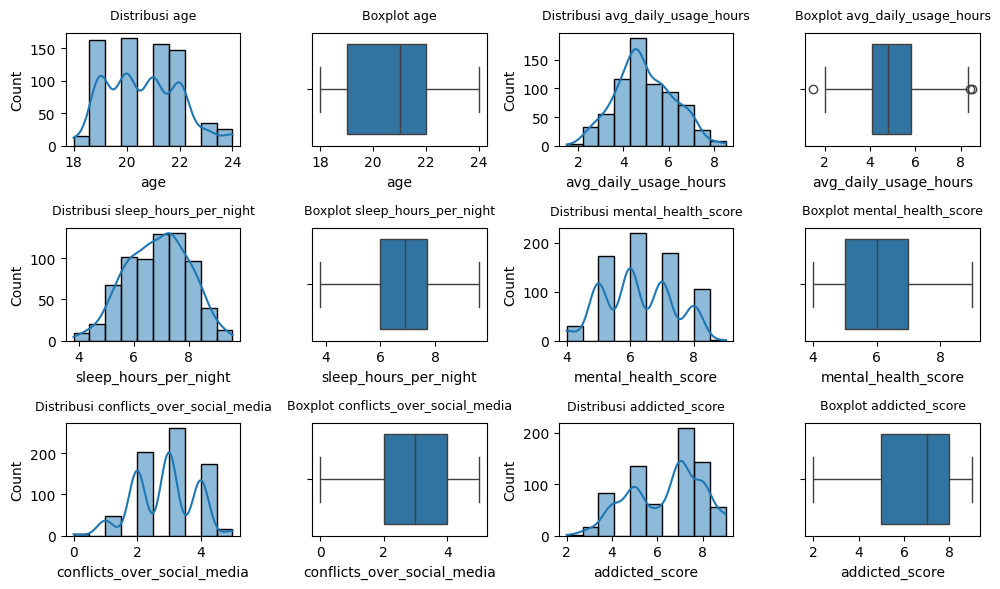

In [16]:
# Distribusi (histogram, boxplot).

import math

# Total plot (2 per kolom: histogram + boxplot)
total_plots = len(numeric_cols) * 2

# Hitung jumlah baris & kolom otomatis
cols = 4  # jumlah kolom tetap 4
rows = math.ceil(total_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 2))
axes = axes.flatten()

plot_index = 0
for col in numeric_cols:
    # Histogram
    sns.histplot(df[col], kde=True, bins=10, ax=axes[plot_index])
    axes[plot_index].set_title(f"Distribusi {col}",fontsize=9 , pad=10)
    plot_index += 1

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[plot_index])
    axes[plot_index].set_title(f"Boxplot {col}",fontsize=9 , pad=10)
    plot_index += 1

# Hapus subplot kosong kalau ada
for i in range(plot_index, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


In [ ]:
# Outliers (IQR).

print("Outliers (IQR)")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nOutliers {col} (IQR):")
    print(outliers[col])

# Outliers (Z-score).
from scipy import stats

print("\nOutliers (Z-score): threshold 3")

z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers_z = np.where(z_scores > 3)  # threshold = 3
print("\nIndeks Outliers (Z-score):", outliers_z)

print("\nOutliers (Z-score): threshold 2.5")

z_scores = np.abs(stats.zscore(df[numeric_cols]))
outliers_z = np.where(z_scores > 2.5)  # threshold = 2.5
print("\nIndeks Outliers (Z-score):", outliers_z)

**Per Kolom (Kategorikal)**

In [ ]:
# relasi kolom antar kategorial (Ratio presentase %)

categorical_cols = df.select_dtypes(include=['object']).columns

rows , cols = 2,3
fig, axes= plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i , col in enumerate (categorical_cols):
    df[col].value_counts(normalize=True).plot(
        kind='bar',
        color="skyblue",
        edgecolor="black" ,
        ax=axes[i]
    )
    axes[i].set_title(f"Proporsi kategori - {col}")
    axes[i].set_ylabel("Proporsi (%)")

# hilangkan subplot kosong jika kolom kategorial < rows*cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Frekuensi dominan & kategori dengan nilai kecil → bisa diputuskan apakah digabung (grouping) atau dihapus

for col in categorical_cols:
    print(f"\nFrekuensi kategori untuk {col}:")
    print(df[col].value_counts())
    print("\nKategori jarang (kurang dari 5%):")
    print(df[col].value_counts(normalize=True)[df[col].value_counts(normalize=True) < 0.05])


In [ ]:
# proporsi kategori target pada tiap kategori prediktor

# Cross-tab (pivot table)
# contoh target kategorikal (misal kita bikin threshold addicted_score > 5)
df["addicted_high"] = (df["addicted_score"] > 5).astype(int)

for col in categorical_cols:
    print(f"\nCross-tab {col} vs addicted_high:")
    print(pd.crosstab(df[col], df["addicted_high"], normalize="index")*100)


In [ ]:
#for col in categorical_cols:
#    plt.figure(figsize=(6,4))
#    sns.barplot(data=df, x=col, y="addicted_score", estimator="mean", errorbar="sd", palette="viridis")
#    plt.title(f"Rata-rata addicted_score per {col}")
#    plt.xticks(rotation=45)
#    plt.show()


## **Relasi antar kolom**

In [ ]:
df[list(numeric_cols)].info()

In [ ]:
# hitung korelasi (numerik vs addicted_score)
corr = df[list(numeric_cols) + ["addicted_score"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi dengan Target")
plt.show()

In [ ]:
print("Apakah 'addicted_score' ada di numeric_cols?", "addicted_score" in numeric_cols)


In [ ]:
# hitung korelasi (numerik vs addicted_score)
corr = df[list(numeric_cols) + ["addicted_score"]].corr()

cols = list(numeric_cols) + ["addicted_score"]
cols = list(dict.fromkeys(cols))  # buang duplikat sambil jaga urutan

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi dengan Target")
plt.show()

In [ ]:

# Korelasi Pearson & Spearman Variabel target untuk dibandingkan dengan penggunaan media sosial
targets = [
    "sleep_hours_per_night",
    "mental_health_score",
    "conflicts_over_social_media",
    "addicted_score"
]

# Layout: 2 kolom, otomatis jumlah baris
cols = 2
rows = -(-len(targets) // cols)  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(12, rows*4))
axes = axes.flatten()

for i, target in enumerate(targets):
    sns.regplot(
        x="avg_daily_usage_hours",
        y=target,
        data=df,
        ax=axes[i],
        scatter_kws={"alpha":0.5},
        line_kws={"color":"red"}
    )
    axes[i].set_title(f"Hubungan Media Sosial vs {target}")
    axes[i].set_xlabel("Jam Media Sosial per Hari")
    axes[i].set_ylabel(target)

# Hilangkan subplot kosong jika jumlahnya ganjil
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Export dataset Clean (addiction.csv/pkl)

# Hasil temuan

* Pendidikan : 27 highschool, 353 Undergraduate, dan 325 Graduate
* Tipe data aman (tidak ada missing value & duplicate)
* Mayoritas responden sejak usia 19 - 22 tahun
* Ditemukan 3 outlier pada avg_daily_usage_hours
*




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Export csv

df.to_csv('/content/drive/MyDrive/Pelatihan/Jun 25_FSDA_Madrid_MIkhael Putra Iswanto/DEEP/DEEP - Students Social Media Addiction/addiction.csv', index=False)


In [ ]:
# Export csv ke dekstop
df.to_csv('addiction_DEEP.csv', index=False)

# Apendix

In [ ]:
addiction = pd.read_csv('/content/drive/MyDrive/Pelatihan/Jun 25_FSDA_Madrid_MIkhael Putra Iswanto/DEEP/DEEP - Students Social Media Addiction/addiction.csv')

In [ ]:

addiction.head()

Menggunakan standar **SMDS (Social Media Disorder Scale)** sebagai fondasi

1. **Preoccupation** (terus kepikiran),
2. **Tolerance** (butuh waktu lebih lama),
3. **Withdrawal** (gelisah saat tidak akses),
4. **Persistence** (gagal mengurangi),
5. **Displacement** (mengabaikan kewajiban),
6. **Problem** (mengalami masalah akibat sosmed),
7. **Deception** (menyembunyikan/berbohong soal pemakaian),
8. **Escape** (menggunakan untuk kabur dari masalah),
9. **Conflict** (konflik dengan orang lain karena sosmed).

Klasifikasi (untuk portofolio)

1–3 (Raw 0–2): Rendah (penggunaan wajar).

4–6 (Raw 3–5): Sedang (risiko awal; edukasi & self-regulation).

7–8 (Raw 6–7): Tinggi (dampak pada tidur/akademik/relasi; butuh intervensi).

9–10 (Raw 8–9): Sangat tinggi (indikasi kuat; perlu rencana tindak lanjut).

In [ ]:
# Klasifikasi Tinggi rendahnya menurut score addicted
for klasifikasi in addiction['Addicted_Score'].unique():
  if klasifikasi >= 1 and klasifikasi <= 3:
    print(f"{klasifikasi}: Rendah (penggunaan wajar).")
  elif klasifikasi >= 4 and klasifikasi <= 6:
    print(f"{klasifikasi}: Sedang (risiko awal; edukasi & self-regulation).")
  elif klasifikasi >= 7 and klasifikasi <= 8:
    print(f"{klasifikasi}: Tinggi (dampak pada tidur/akademik/relasi; butuh intervensi).")
  elif klasifikasi >= 9 and klasifikasi <= 10:
    print(f"{klasifikasi}: Sangat tinggi (indikasi kuat; perlu rencana tindak lanjut).")

print("\nValue Counts for Addicted_Score:")
print(addiction['Addicted_Score'].value_counts().sort_index(ascending=False))